## ADJACENCY MATRIX WALKS

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library imports
import itertools

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

### Setup

This reproduces the graph from *Advanced Portfolio Optimization* (Cajas), Ch. 13
"Graph Theory-Based Portfolios", §13.1.2 (`../assets/advanced-portfolio-optimization-cajas.pdf`).

Graph $G = (V, E)$ with:

- $V = \{v_1, v_2, v_3, v_4, v_5, v_6\}$
- $E = \{(v_1,v_2), (v_1,v_5), (v_2,v_3), (v_2,v_4), (v_3,v_4), (v_4,v_5), (v_4,v_6), (v_6,v_6)\}$

Note $(v_6, v_6)$ is a self-loop.

In [2]:
nodes = ["v1", "v2", "v3", "v4", "v5", "v6"]
edges = [
    ("v1", "v2"),
    ("v1", "v5"),
    ("v2", "v3"),
    ("v2", "v4"),
    ("v3", "v4"),
    ("v4", "v5"),
    ("v4", "v6"),
    ("v6", "v6"),
]

index = {node: i for i, node in enumerate(nodes)}
n = len(nodes)

# Adjacency matrix: A[i, j] = number of edges directly connecting v_i and v_j.
A = np.zeros((n, n), dtype=int)
for u, v in edges:
    i, j = index[u], index[v]
    A[i, j] += 1
    if i != j:
        A[j, i] += 1

pd.DataFrame(A, index=nodes, columns=nodes)

,v1,v2,v3,v4,v5,v6
v1,0,1,0,0,1,0
v2,1,0,1,1,0,0
v3,0,1,0,1,0,0
v4,0,1,1,0,1,1
v5,1,0,0,1,0,0
v6,0,0,0,1,0,1


### The graph, drawn

A schematic layout (not a reproduction of the book's figure, which wasn't extractable
from the PDF) -- just enough to see the edges and the self-loop at $v_6$.

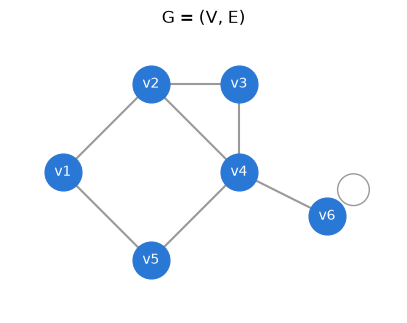

In [3]:
positions = {
    "v1": (0.0, 1.0),
    "v2": (1.0, 2.0),
    "v3": (2.0, 2.0),
    "v4": (2.0, 1.0),
    "v5": (1.0, 0.0),
    "v6": (3.0, 0.5),
}

fig, ax = plt.subplots(figsize=(5, 4))

for u, v in edges:
    if u == v:
        continue
    x0, y0 = positions[u]
    x1, y1 = positions[v]
    ax.plot([x0, x1], [y0, y1], color="#999999", zorder=1)

for node, (x, y) in positions.items():
    ax.scatter(x, y, s=700, color="#2a78d6", zorder=2)
    ax.annotate(node, (x, y), ha="center", va="center", color="white", zorder=3)

# Self-loop at v6.
x, y = positions["v6"]
loop = plt.Circle((x + 0.3, y + 0.3), 0.18, fill=False, color="#999999", zorder=1)
ax.add_patch(loop)

ax.set_xlim(-0.6, 3.8)
ax.set_ylim(-0.6, 2.6)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("G = (V, E)")
plt.show()

### The property

$$(A^k)_{ij} = \text{number of walks of length } k \text{ between } v_i \text{ and } v_j$$

A *walk* of length $k$ is any edge sequence $v_i \to v_{m_1} \to \dots \to v_j$ ($k$ edges;
nodes/edges may repeat).

**Why**: by induction on $k$. Base case $k=1$: $A_{ij}$ is literally the edge count between
$v_i, v_j$, i.e. the number of length-1 walks. Inductive step:

$$(A^k)_{ij} = \sum_m (A^{k-1})_{im} \, A_{mj}$$

Every length-$k$ walk from $v_i$ to $v_j$ decomposes uniquely into a length-$(k-1)$ walk
ending at some $v_m$ followed by one final edge $v_m \to v_j$ (its last step). Summing over
all possible $m$ counts every length-$k$ walk exactly once -- which is exactly what matrix
multiplication computes.

In [4]:
A_2 = np.linalg.matrix_power(A, 2)
pd.DataFrame(A_2, index=nodes, columns=nodes)

,v1,v2,v3,v4,v5,v6
v1,2,0,1,2,0,0
v2,0,3,1,1,2,1
v3,1,1,2,1,1,1
v4,2,1,1,4,0,1
v5,0,2,1,0,2,1
v6,0,1,1,1,1,2


### Verify by brute force

Enumerate every literal walk of length $k$ as a node sequence and check the count against
$(A^k)_{ij}$ -- an independent check that doesn't rely on the inductive argument above.

In [5]:
def enumerate_walks(A, i, j, k):
    """Enumerate every walk of length k from node i to node j by brute force."""
    walks = []
    for middle in itertools.product(range(A.shape[0]), repeat=k - 1):
        sequence = (i,) + middle + (j,)
        if all(A[sequence[t], sequence[t + 1]] > 0 for t in range(k)):
            walks.append(sequence)
    return walks


i, j, k = index["v1"], index["v4"], 2
walks = enumerate_walks(A, i, j, k)
for walk in walks:
    print(" -> ".join(nodes[node] for node in walk))

print(f"\nbrute-force count: {len(walks)}")
print(f"(A^{k})[{nodes[i]}, {nodes[j]}] = {A_2[i, j]}")
assert len(walks) == A_2[i, j]

v1 -> v2 -> v4
v1 -> v5 -> v4

brute-force count: 2
(A^2)[v1, v4] = 2


In [6]:
for k in (1, 2, 3):
    Ak = np.linalg.matrix_power(A, k)
    for i in range(n):
        for j in range(n):
            assert len(enumerate_walks(A, i, j, k)) == Ak[i, j]

print("brute-force walk counts match A^k for every pair, k = 1, 2, 3")

brute-force walk counts match A^k for every pair, k = 1, 2, 3


### From counts to connectivity: $B_k$ and $B_{1,l}$

$(A^k)_{ij}$ is a *count*, not a yes/no answer. The book turns it into a binary connection
matrix (Eq. 13.1):

$$B_k = \mathbb{1}_{x \ge 1}(A^k + I_n) - I_n$$

$\mathbb{1}_{x \ge 1}(\cdot)$ collapses any positive count to 1; adding then subtracting
$I_n$ thresholds the diagonal the same way without creating spurious self-connections.
$B_k$ tells us whether $v_i, v_j$ are connected by *some* walk of length exactly $k$.

This generalizes to the range connection matrix (Eq. 13.2), connectivity via any walk of
length between $1$ and $l$:

$$B_{1,l} = \mathbb{1}_{x \ge 1}\left(\sum_{k=1}^{l} B_k\right)$$

Code below follows the book's own "Python code 13.2" for these two matrices.

In [7]:
def connection_matrix(A, k):
    """Binary indicator of whether v_i, v_j are connected by a walk of length k (Eq. 13.1)."""
    I_n = np.identity(A.shape[0], dtype=int)
    Ak = np.linalg.matrix_power(A, k)
    return np.where(Ak + I_n >= 1, 1, 0) - I_n


def range_connection_matrix(A, walk_size):
    """Binary indicator of connectivity via a walk of length 1..walk_size (Eq. 13.2)."""
    B = np.zeros_like(A)
    for k in range(1, walk_size + 1):
        B += connection_matrix(A, k)
    return np.where(B >= 1, 1, 0)


B_2 = connection_matrix(A, 2)
B_1_2 = range_connection_matrix(A, 2)

print("B_2 -- connected via a walk of exactly length 2:")
display(pd.DataFrame(B_2, index=nodes, columns=nodes))

print("\nB_1,2 -- connected via a walk of length 1 or 2:")
display(pd.DataFrame(B_1_2, index=nodes, columns=nodes))

B_2 -- connected via a walk of exactly length 2:


,v1,v2,v3,v4,v5,v6
v1,0,0,1,1,0,0
v2,0,0,1,1,1,1
v3,1,1,0,1,1,1
v4,1,1,1,0,0,1
v5,0,1,1,0,0,1
v6,0,1,1,1,1,0



B_1,2 -- connected via a walk of length 1 or 2:


,v1,v2,v3,v4,v5,v6
v1,0,1,1,1,1,0
v2,1,0,1,1,1,1
v3,1,1,0,1,1,1
v4,1,1,1,0,1,1
v5,1,1,1,1,0,1
v6,0,1,1,1,1,0


### Why it matters for graph-theory-based portfolios

$B_{1,l}$ turns a raw price/return network (e.g. built from a correlation-derived
adjacency matrix) into a binary mask of "which asset pairs are reachable within $l$ steps."
That mask is what later gets folded into the portfolio optimization -- e.g. as a
connectivity or grouping constraint -- rather than the raw walk *counts*, which don't
have a natural portfolio interpretation on their own.